## 1. Import Required Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Model and preprocessing
import joblib
import glob
from sklearn.preprocessing import LabelEncoder

# Explainability libraries
import shap
from lime import lime_tabular

print("✓ All libraries imported successfully!")
print(f"SHAP version: {shap.__version__}")

✓ All libraries imported successfully!
SHAP version: 0.50.0


## 2. Load Prescriptive Model Package from Phase 2

In [2]:
def load_prescriptive_model():
    """
    Load the prescriptive model package from Phase 2.
    """
    # Find the most recent prescriptive model file
    files = glob.glob('prescriptive_model_package_*.joblib')
    if len(files) == 0:
        print("⚠️  No prescriptive model package found!")
        print("   Please run Phase 2 first to export the model.")
        return None
    
    # Use the most recent file
    latest_file = sorted(files)[-1]
    
    print("="*80)
    print("LOADING PRESCRIPTIVE MODEL FROM PHASE 2")
    print("="*80)
    
    prescriptive_pkg = joblib.load(latest_file)
    
    print(f"\n✓ Loaded: {latest_file}")
    print(f"\nPackage Contents:")
    print(f"  • Predictive Model: {prescriptive_pkg['model_name']} ({prescriptive_pkg['model_accuracy']:.2%} accuracy)")
    print(f"  • Optimization Method: {prescriptive_pkg['optimization_method']}")
    print(f"  • Sample: {prescriptive_pkg['sample_optimization']['current_class']} → {prescriptive_pkg['sample_optimization']['optimized_class']}")
    print(f"  • Domain Correctness: {prescriptive_pkg['correctness_report']['correctness_pct']:.1f}%")
    print("="*80)
    
    return prescriptive_pkg

# Load prescriptive model
prescriptive_pkg = load_prescriptive_model()

LOADING PRESCRIPTIVE MODEL FROM PHASE 2

✓ Loaded: prescriptive_model_package_20251210_113932.joblib

Package Contents:
  • Predictive Model: XGBoost (90.23% accuracy)
  • Optimization Method: Goal-Seeking with Domain Constraints
  • Sample: slow → fast
  • Domain Correctness: 100.0%


## 3. Load Dataset and Prepare Data

In [6]:
# Load cleaned dataset
df = pd.read_csv('cleaned_website_performance_dataset_20251207_145008.csv')
print(f"Dataset loaded: {df.shape[0]} samples, {df.shape[1]} features")

# Get model components
model = prescriptive_pkg['predictive_model']
scaler = prescriptive_pkg['scaler']
feature_names = prescriptive_pkg['feature_names']
target_encoder = prescriptive_pkg['encoders']['target']
category_encoder = prescriptive_pkg['encoders'].get('Category', None)

# Get base features (first 15 are raw features)
base_features = feature_names[:15]
print(f"\nBase features: {base_features}")

# Create engineered features to match the model's expected features
df_features = df[base_features].copy()

# Encode Category column if needed
if category_encoder is not None and 'Category' in df_features.columns:
    # Handle unknown categories
    known_categories = category_encoder.classes_
    df_features['Category'] = df_features['Category'].apply(
        lambda x: x if x in known_categories else known_categories[0]
    )
    df_features['Category'] = category_encoder.transform(df_features['Category'])

# Feature engineering (same as Phase 1)
df_features['Size_LoadTime_Ratio'] = df_features['Page Size (KB)'] / (df_features['Load Time(s)'] + 1e-6)
df_features['Total_Time'] = df_features['Response Time(s)'] + df_features['Load Time(s)']
df_features['Throughput_ResponseTime_Ratio'] = df_features['Throughput'] / (df_features['Response Time(s)'] + 1e-6)
df_features['Log_Page_Size'] = np.log1p(df_features['Page Size (KB)'])
df_features['Log_Throughput'] = np.log1p(df_features['Throughput'])

# Verify all features are present
X_original = df_features[feature_names].copy()
X_scaled = scaler.transform(X_original)
y = target_encoder.transform(df['Performance_Label'])

print(f"\n✓ Features prepared: {X_original.shape}")
print(f"✓ Target classes: {target_encoder.classes_}")

Dataset loaded: 885 samples, 27 features

Base features: ['Category', 'Page Size (KB)', 'Load Time(s)', 'Response Time(s)', 'Throughput', 'performance_score', 'lcp', 'fcp', 'cls', 'tti', 'tbt', 'speed_index', 'total_byte_weight', 'num_requests', 'unused_js']

✓ Features prepared: (885, 20)
✓ Target classes: ['fast' 'medium' 'slow']


## 4. SHAP Analysis for Prescriptive Explanations

In [7]:
# Create SHAP explainer
print("="*80)
print("CREATING SHAP EXPLAINER FOR PRESCRIPTIVE MODEL")
print("="*80)

shap_explainer = shap.TreeExplainer(model)
shap_values = shap_explainer.shap_values(X_scaled)

print(f"\n✓ SHAP explainer created!")
print(f"  SHAP values shape: {np.array(shap_values).shape}")
print("="*80)

CREATING SHAP EXPLAINER FOR PRESCRIPTIVE MODEL

✓ SHAP explainer created!
  SHAP values shape: (885, 20, 3)

✓ SHAP explainer created!
  SHAP values shape: (885, 20, 3)


EXPLAINING PRESCRIPTIVE RECOMMENDATIONS WITH SHAP

Optimization: slow → fast
P(fast): 0.001 → 0.997


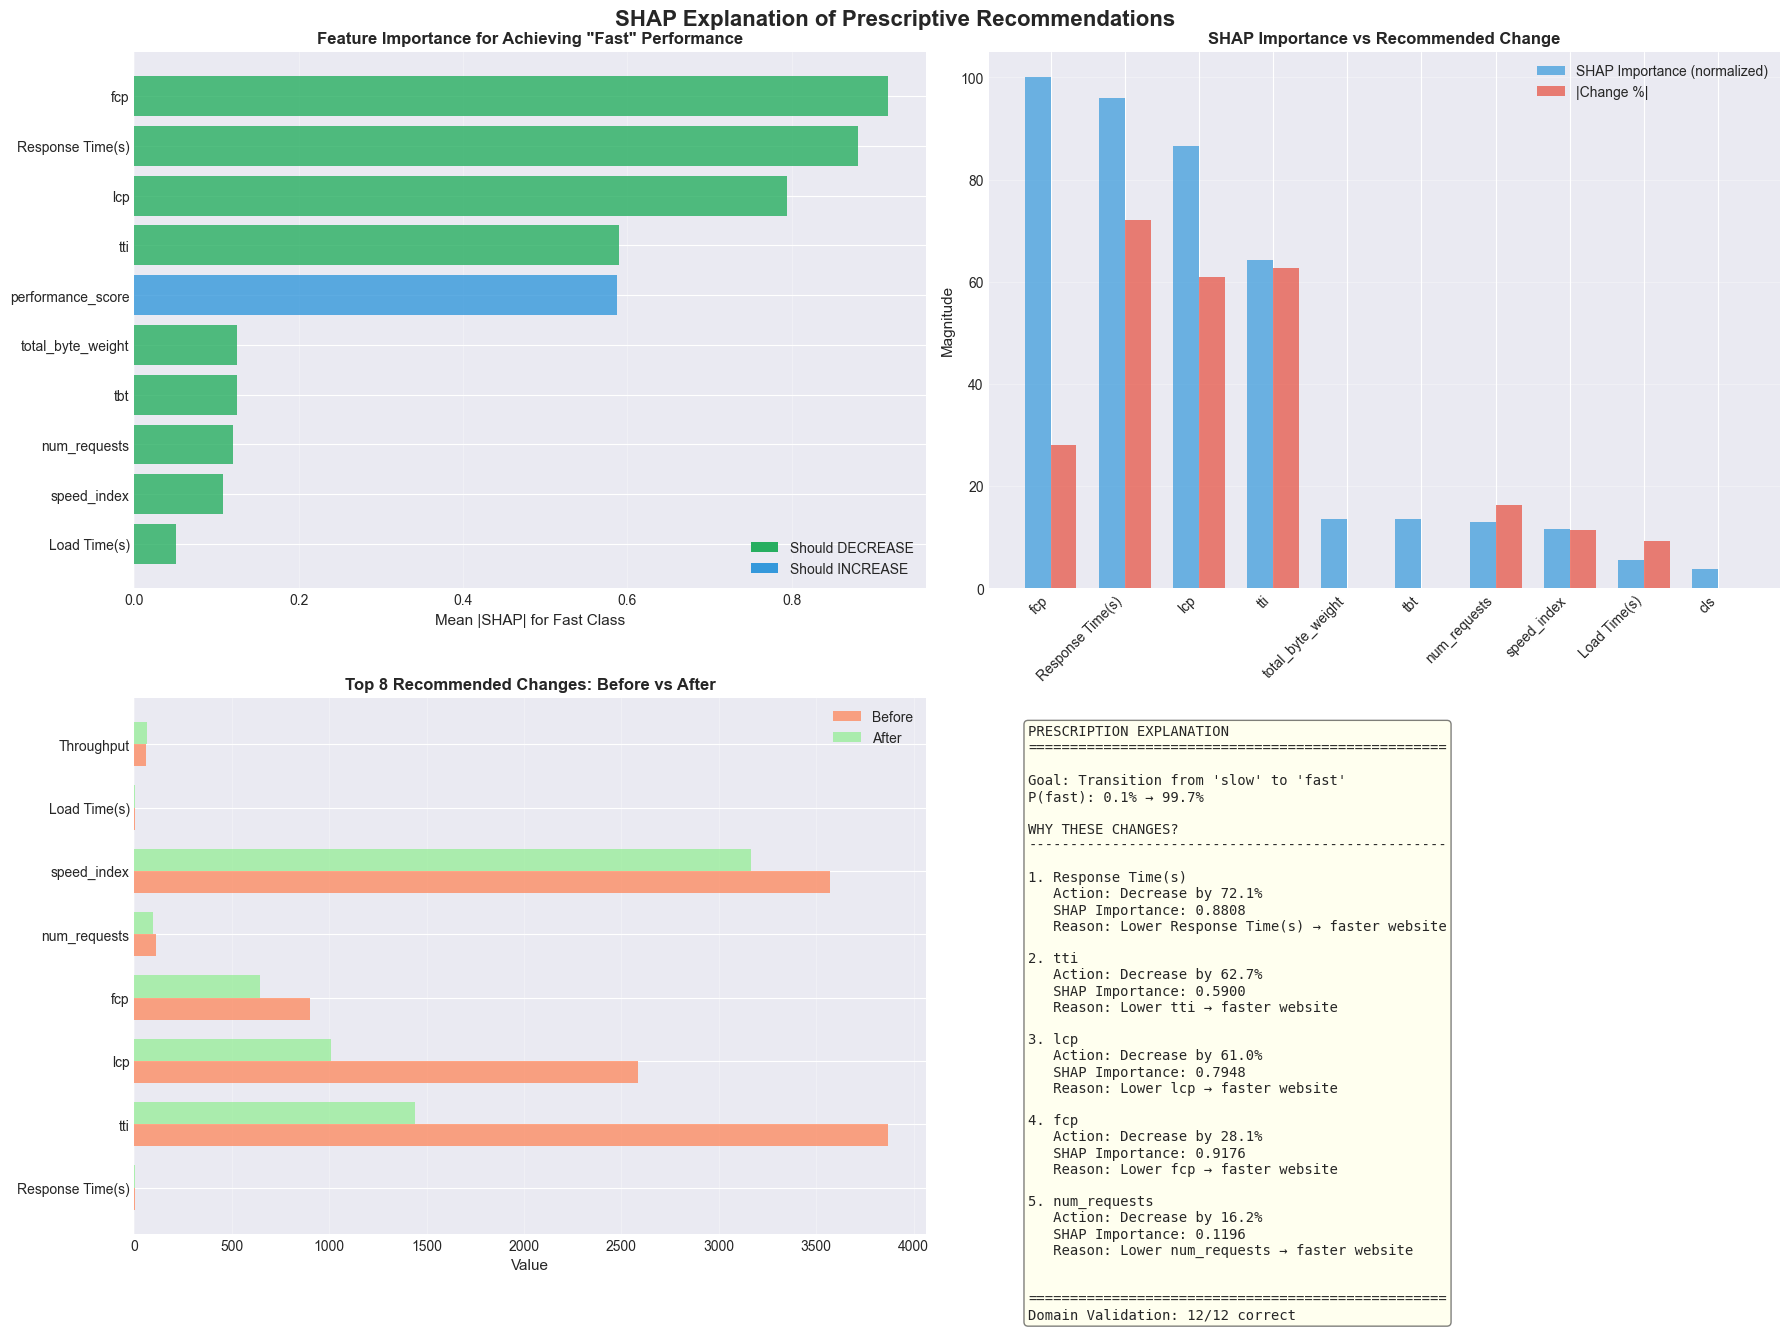


📊 Key Insights:
  • 8 features recommended for change
  • Top driver: Response Time(s) (-72.1%)
  • All changes align with domain knowledge: True


In [8]:
def explain_prescription_with_shap(prescriptive_pkg, shap_values, feature_names):
    """
    Use SHAP to explain why specific prescription changes were recommended.
    
    This function analyzes the SHAP values for both:
    1. The BEFORE state (original website features)
    2. The AFTER state (optimized website features)
    
    And shows how each change contributed to improving performance.
    """
    print("="*80)
    print("EXPLAINING PRESCRIPTIVE RECOMMENDATIONS WITH SHAP")
    print("="*80)
    
    # Get optimization data
    sample = prescriptive_pkg['sample_optimization']
    improvements = sample['improvements']
    
    # Get base features (15 core features)
    base_features = feature_names[:15]
    
    print(f"\nOptimization: {sample['current_class']} → {sample['optimized_class']}")
    print(f"P(fast): {sample['current_proba'][0]:.3f} → {sample['optimized_proba'][0]:.3f}")
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    fig.suptitle('SHAP Explanation of Prescriptive Recommendations', fontsize=16, fontweight='bold')
    
    # 1. Feature importance for "fast" class
    if isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
        shap_fast = np.abs(shap_values[:, :, 0]).mean(axis=0)
    else:
        shap_fast = np.abs(shap_values[0]).mean(axis=0)
    
    # Get only base features
    shap_base = shap_fast[:15]
    sorted_idx = np.argsort(shap_base)[::-1]
    
    # Plot bar chart
    colors = ['#27ae60' if base_features[i] in prescriptive_pkg['domain_constraints']['metrics_to_reduce'] 
              else '#3498db' if base_features[i] in prescriptive_pkg['domain_constraints']['metrics_to_increase']
              else '#95a5a6' for i in sorted_idx[:10]]
    
    axes[0, 0].barh(range(10), shap_base[sorted_idx[:10]][::-1], color=colors[::-1], alpha=0.8)
    axes[0, 0].set_yticks(range(10))
    axes[0, 0].set_yticklabels([base_features[i] for i in sorted_idx[:10]][::-1])
    axes[0, 0].set_xlabel('Mean |SHAP| for Fast Class', fontsize=11)
    axes[0, 0].set_title('Feature Importance for Achieving "Fast" Performance', fontweight='bold')
    axes[0, 0].grid(axis='x', alpha=0.3)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#27ae60', label='Should DECREASE'),
                      Patch(facecolor='#3498db', label='Should INCREASE')]
    axes[0, 0].legend(handles=legend_elements, loc='lower right')
    
    # 2. Recommended changes vs SHAP importance
    change_data = []
    for i, feat in enumerate(base_features):
        if feat in improvements:
            imp = improvements[feat]
            change_data.append({
                'Feature': feat,
                'Change (%)': imp['pct_change'],
                'SHAP Importance': shap_base[i],
                'Correct Direction': imp['correct_direction']
            })
    
    change_df = pd.DataFrame(change_data)
    change_df = change_df.sort_values('SHAP Importance', ascending=False).head(10)
    
    x_pos = np.arange(len(change_df))
    width = 0.35
    
    # Normalize SHAP for visualization
    max_shap = change_df['SHAP Importance'].max()
    normalized_shap = change_df['SHAP Importance'] / max_shap * 100
    
    bars1 = axes[0, 1].bar(x_pos - width/2, normalized_shap, width, label='SHAP Importance (normalized)', 
                          color='#3498db', alpha=0.7)
    bars2 = axes[0, 1].bar(x_pos + width/2, np.abs(change_df['Change (%)']), width, 
                          label='|Change %|', color='#e74c3c', alpha=0.7)
    
    axes[0, 1].set_xticks(x_pos)
    axes[0, 1].set_xticklabels(change_df['Feature'], rotation=45, ha='right')
    axes[0, 1].set_ylabel('Magnitude', fontsize=11)
    axes[0, 1].set_title('SHAP Importance vs Recommended Change', fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    # 3. Before vs After values for top changes
    top_changes = sorted(improvements.items(), key=lambda x: abs(x[1]['pct_change']), reverse=True)[:8]
    
    feat_names = [x[0] for x in top_changes]
    current = [x[1]['current'] for x in top_changes]
    optimized = [x[1]['optimized'] for x in top_changes]
    
    x = np.arange(len(feat_names))
    
    axes[1, 0].barh(x - width/2, current, width, label='Before', alpha=0.7, color='coral')
    axes[1, 0].barh(x + width/2, optimized, width, label='After', alpha=0.7, color='lightgreen')
    axes[1, 0].set_yticks(x)
    axes[1, 0].set_yticklabels(feat_names)
    axes[1, 0].set_xlabel('Value', fontsize=11)
    axes[1, 0].set_title('Top 8 Recommended Changes: Before vs After', fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(axis='x', alpha=0.3)
    
    # 4. Explanation summary
    axes[1, 1].axis('off')
    
    explanation_text = "PRESCRIPTION EXPLANATION\n"
    explanation_text += "="*50 + "\n\n"
    explanation_text += f"Goal: Transition from '{sample['current_class']}' to 'fast'\n"
    explanation_text += f"P(fast): {sample['current_proba'][0]:.1%} → {sample['optimized_proba'][0]:.1%}\n\n"
    
    explanation_text += "WHY THESE CHANGES?\n"
    explanation_text += "-"*50 + "\n\n"
    
    # Get top 5 changes with explanations
    for i, (feat, data) in enumerate(top_changes[:5], 1):
        shap_idx = base_features.index(feat) if feat in base_features else -1
        shap_imp = shap_base[shap_idx] if shap_idx >= 0 else 0
        
        direction = "Decrease" if data['change'] < 0 else "Increase"
        
        explanation_text += f"{i}. {feat}\n"
        explanation_text += f"   Action: {direction} by {abs(data['pct_change']):.1f}%\n"
        explanation_text += f"   SHAP Importance: {shap_imp:.4f}\n"
        
        # Add domain explanation
        if feat in prescriptive_pkg['domain_constraints']['metrics_to_reduce']:
            explanation_text += f"   Reason: Lower {feat} → faster website\n"
        elif feat in prescriptive_pkg['domain_constraints']['metrics_to_increase']:
            explanation_text += f"   Reason: Higher {feat} → better performance\n"
        explanation_text += "\n"
    
    explanation_text += "\n" + "="*50 + "\n"
    explanation_text += f"Domain Validation: {sample['domain_validation']['correct_direction']}/{sample['domain_validation']['total_changes']} correct"
    
    axes[1, 1].text(0.05, 0.95, explanation_text, 
                   fontsize=10, family='monospace',
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Key Insights:")
    print(f"  • {len(top_changes)} features recommended for change")
    print(f"  • Top driver: {top_changes[0][0]} ({top_changes[0][1]['pct_change']:+.1f}%)")
    print(f"  • All changes align with domain knowledge: {sample['domain_validation']['correct_direction'] == sample['domain_validation']['total_changes']}")
    print("="*80)
    
    return change_df

# Explain prescriptions with SHAP
prescription_explanation = explain_prescription_with_shap(prescriptive_pkg, shap_values, feature_names)

## 5. LIME Analysis for Local Prescriptive Explanations

In [9]:
# Create LIME explainer
print("="*80)
print("CREATING LIME EXPLAINER FOR PRESCRIPTIVE ANALYSIS")
print("="*80)

lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_original.values,
    feature_names=feature_names,
    class_names=list(target_encoder.classes_),
    mode='classification',
    discretize_continuous=True,
    random_state=42
)

print("\n✓ LIME explainer created!")
print(f"  Training samples: {X_original.shape[0]}")
print(f"  Features: {len(feature_names)}")
print("="*80)

CREATING LIME EXPLAINER FOR PRESCRIPTIVE ANALYSIS

✓ LIME explainer created!
  Training samples: 885
  Features: 20


LIME LOCAL EXPLANATIONS FOR PRESCRIPTIVE OPTIMIZATION
  Current features: 20, Optimized features: 20

📊 Explaining BEFORE optimization (slow website):
📊 Explaining AFTER optimization (fast website):


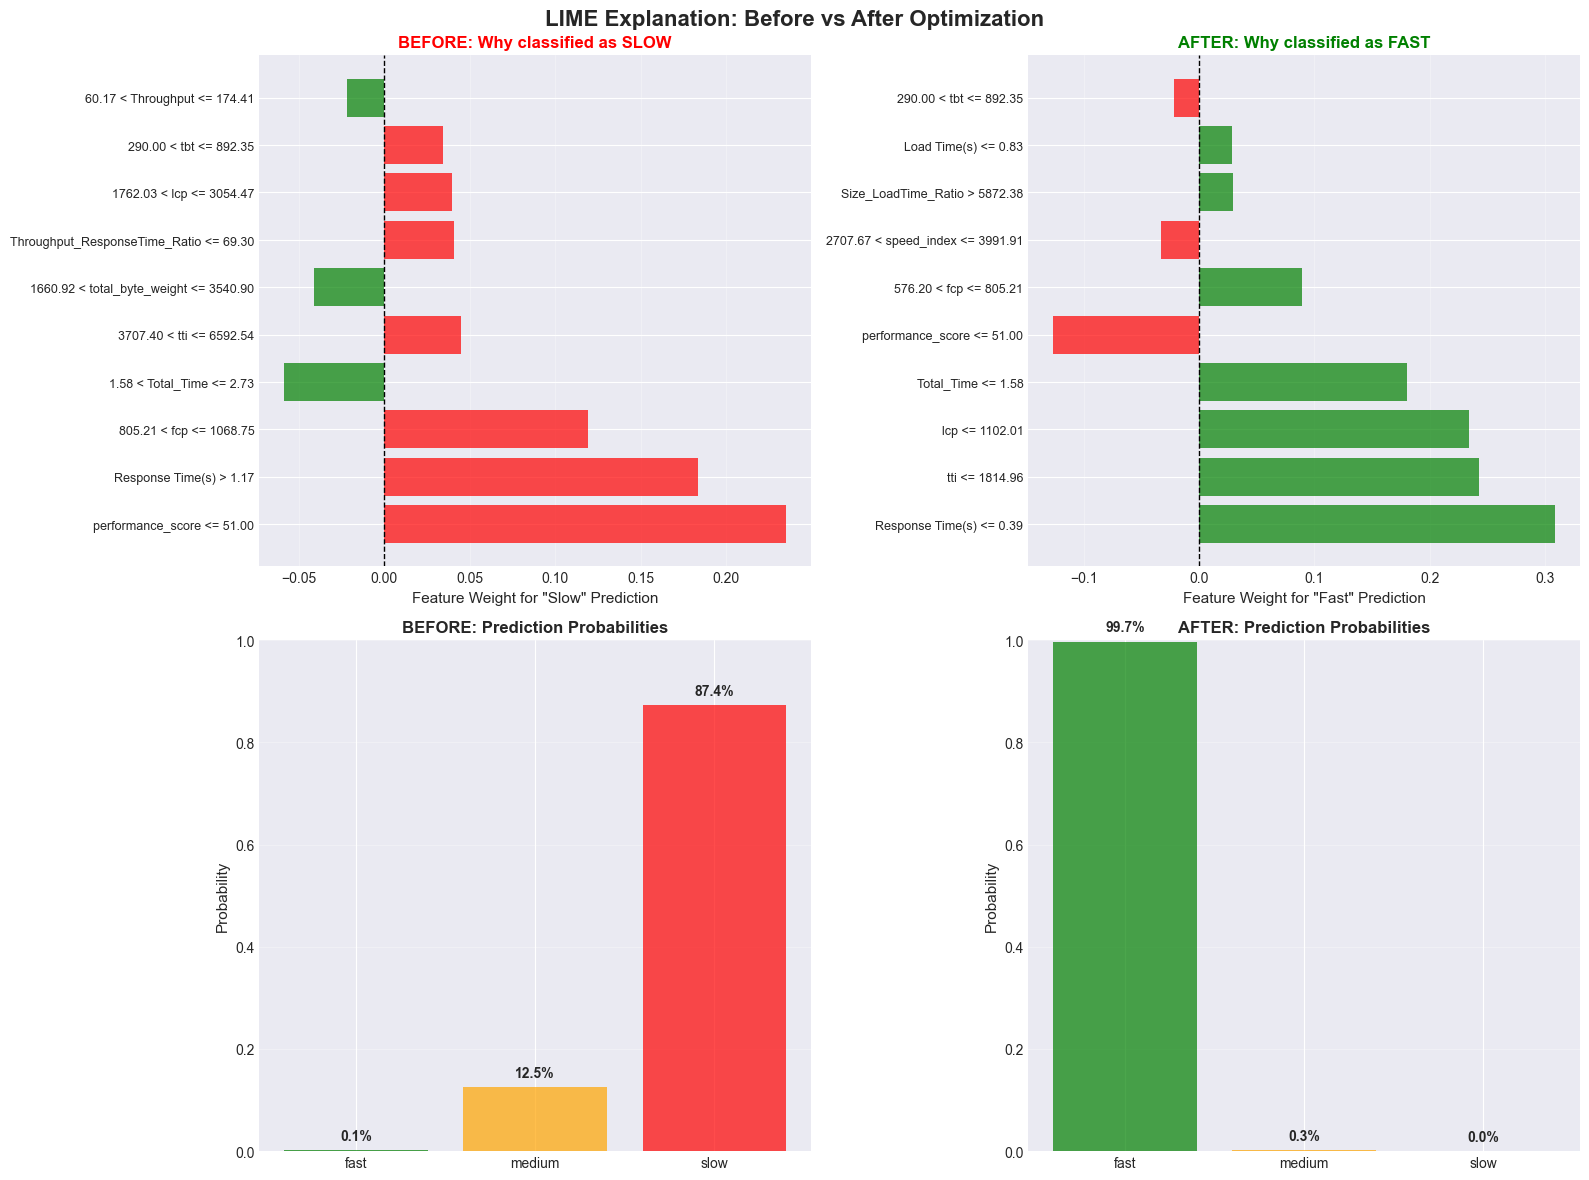


LIME ANALYSIS SUMMARY

BEFORE Optimization:
  • Classified as: slow (87.4%)
  • Top factor for 'slow': performance_score <= 51.00

AFTER Optimization:
  • Classified as: fast (99.7%)
  • Top factor for 'fast': Response Time(s) <= 0.39

📈 Improvement: P(fast) increased by +99.6%


In [12]:
def add_engineered_features(base_array, feature_names):
    """Add engineered features to the base 15-feature array to create 20-feature array."""
    # base_array has 15 features in order: Category, Page Size (KB), Load Time(s), Response Time(s), Throughput, ...
    # Feature indices: Page Size (KB)=1, Load Time(s)=2, Response Time(s)=3, Throughput=4
    
    page_size = base_array[1]
    load_time = base_array[2]
    response_time = base_array[3]
    throughput = base_array[4]
    
    # Compute engineered features
    size_loadtime_ratio = page_size / (load_time + 1e-6)
    total_time = response_time + load_time
    throughput_response_ratio = throughput / (response_time + 1e-6)
    log_page_size = np.log1p(page_size)
    log_throughput = np.log1p(throughput)
    
    # Concatenate to form 20-feature array
    return np.concatenate([base_array, [size_loadtime_ratio, total_time, throughput_response_ratio, log_page_size, log_throughput]])

def explain_prescription_with_lime(prescriptive_pkg, lime_explainer, X_original, scaler, model, feature_names):
    """
    Use LIME to explain the prescriptive optimization at a local level.
    """
    print("="*80)
    print("LIME LOCAL EXPLANATIONS FOR PRESCRIPTIVE OPTIMIZATION")
    print("="*80)
    
    sample = prescriptive_pkg['sample_optimization']
    current_values_base = sample['current_values']  # 15 features
    optimized_values_base = sample['optimized_values']  # 15 features
    
    # Add engineered features to create 20-feature arrays
    current_array = add_engineered_features(current_values_base, feature_names)
    optimized_array = add_engineered_features(optimized_values_base, feature_names)
    
    print(f"  Current features: {len(current_array)}, Optimized features: {len(optimized_array)}")
    
    # Wrapper function for LIME
    def predict_fn(X):
        X_scaled = scaler.transform(X)
        return model.predict_proba(X_scaled)
    
    # Generate LIME explanations for both states
    print("\n📊 Explaining BEFORE optimization (slow website):")
    explanation_before = lime_explainer.explain_instance(
        data_row=current_array,
        predict_fn=predict_fn,
        num_features=10,
        top_labels=3
    )
    
    print("📊 Explaining AFTER optimization (fast website):")
    explanation_after = lime_explainer.explain_instance(
        data_row=optimized_array,
        predict_fn=predict_fn,
        num_features=10,
        top_labels=3
    )
    
    # Visualize
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('LIME Explanation: Before vs After Optimization', fontsize=16, fontweight='bold')
    
    # Class indices: 0=fast, 1=medium, 2=slow
    class_names = ['fast', 'medium', 'slow']
    
    # 1. BEFORE - factors pushing toward slow
    exp_before_slow = explanation_before.as_list(label=2)  # slow class
    features_before = [item[0] for item in exp_before_slow[:10]]
    weights_before = [item[1] for item in exp_before_slow[:10]]
    colors_before = ['red' if w > 0 else 'green' for w in weights_before]
    
    axes[0, 0].barh(range(len(features_before)), weights_before, color=colors_before, alpha=0.7)
    axes[0, 0].set_yticks(range(len(features_before)))
    axes[0, 0].set_yticklabels(features_before, fontsize=9)
    axes[0, 0].set_xlabel('Feature Weight for "Slow" Prediction', fontsize=11)
    axes[0, 0].axvline(x=0, color='black', linestyle='--', linewidth=1)
    axes[0, 0].set_title('BEFORE: Why classified as SLOW', fontweight='bold', color='red')
    axes[0, 0].grid(axis='x', alpha=0.3)
    
    # 2. AFTER - factors pushing toward fast
    exp_after_fast = explanation_after.as_list(label=0)  # fast class
    features_after = [item[0] for item in exp_after_fast[:10]]
    weights_after = [item[1] for item in exp_after_fast[:10]]
    colors_after = ['green' if w > 0 else 'red' for w in weights_after]
    
    axes[0, 1].barh(range(len(features_after)), weights_after, color=colors_after, alpha=0.7)
    axes[0, 1].set_yticks(range(len(features_after)))
    axes[0, 1].set_yticklabels(features_after, fontsize=9)
    axes[0, 1].set_xlabel('Feature Weight for "Fast" Prediction', fontsize=11)
    axes[0, 1].axvline(x=0, color='black', linestyle='--', linewidth=1)
    axes[0, 1].set_title('AFTER: Why classified as FAST', fontweight='bold', color='green')
    axes[0, 1].grid(axis='x', alpha=0.3)
    
    # 3. Prediction probabilities before
    proba_before = predict_fn(current_array.reshape(1, -1))[0]
    axes[1, 0].bar(class_names, proba_before, color=['green', 'orange', 'red'], alpha=0.7)
    axes[1, 0].set_ylabel('Probability', fontsize=11)
    axes[1, 0].set_title('BEFORE: Prediction Probabilities', fontweight='bold')
    axes[1, 0].set_ylim([0, 1])
    axes[1, 0].grid(axis='y', alpha=0.3)
    for i, p in enumerate(proba_before):
        axes[1, 0].text(i, p + 0.02, f'{p:.1%}', ha='center', fontweight='bold')
    
    # 4. Prediction probabilities after
    proba_after = predict_fn(optimized_array.reshape(1, -1))[0]
    axes[1, 1].bar(class_names, proba_after, color=['green', 'orange', 'red'], alpha=0.7)
    axes[1, 1].set_ylabel('Probability', fontsize=11)
    axes[1, 1].set_title('AFTER: Prediction Probabilities', fontweight='bold')
    axes[1, 1].set_ylim([0, 1])
    axes[1, 1].grid(axis='y', alpha=0.3)
    for i, p in enumerate(proba_after):
        axes[1, 1].text(i, p + 0.02, f'{p:.1%}', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*80)
    print("LIME ANALYSIS SUMMARY")
    print("="*80)
    print(f"\nBEFORE Optimization:")
    print(f"  • Classified as: {class_names[np.argmax(proba_before)]} ({max(proba_before):.1%})")
    print(f"  • Top factor for 'slow': {features_before[0]}")
    
    print(f"\nAFTER Optimization:")
    print(f"  • Classified as: {class_names[np.argmax(proba_after)]} ({max(proba_after):.1%})")
    print(f"  • Top factor for 'fast': {features_after[0]}")
    
    print(f"\n📈 Improvement: P(fast) increased by {(proba_after[0] - proba_before[0])*100:+.1f}%")
    print("="*80)
    
    return explanation_before, explanation_after

# Generate LIME explanations for prescriptive optimization
lime_before, lime_after = explain_prescription_with_lime(
    prescriptive_pkg, lime_explainer, X_original, scaler, model, feature_names
)

## 6. Human-Readable Prescription Explanation

In [13]:
def generate_human_readable_explanation(prescriptive_pkg):
    """
    Generate a human-readable explanation of the optimization recommendations.
    This is designed for non-technical stakeholders.
    """
    print("="*80)
    print("HUMAN-READABLE PRESCRIPTION EXPLANATION")
    print("="*80)
    
    sample = prescriptive_pkg['sample_optimization']
    domain = prescriptive_pkg['domain_constraints']
    improvements = sample['improvements']
    
    print(f"\n📊 WEBSITE PERFORMANCE OPTIMIZATION REPORT")
    print(f"{'='*60}")
    
    print(f"\n🔍 CURRENT STATUS:")
    print(f"   Performance Class: {sample['current_class'].upper()}")
    print(f"   Probability of being 'Fast': {sample['current_proba'][0]:.1%}")
    
    print(f"\n🎯 AFTER OPTIMIZATION:")
    print(f"   Performance Class: {sample['optimized_class'].upper()}")
    print(f"   Probability of being 'Fast': {sample['optimized_proba'][0]:.1%}")
    
    print(f"\n📈 IMPROVEMENT: {(sample['optimized_proba'][0] - sample['current_proba'][0])*100:+.1f}% increase in fast probability")
    
    print(f"\n{'='*60}")
    print("📋 RECOMMENDED ACTIONS (Prioritized by Impact)")
    print(f"{'='*60}")
    
    # Sort by impact
    sorted_improvements = sorted(
        [(k, v) for k, v in improvements.items() if abs(v['pct_change']) > 0.1],
        key=lambda x: abs(x[1]['pct_change']),
        reverse=True
    )
    
    # Explanations for each feature
    feature_explanations = {
        'Response Time(s)': {
            'why': 'Faster server response improves overall page load speed',
            'how': 'Optimize database queries, use caching, upgrade server resources'
        },
        'Load Time(s)': {
            'why': 'Lower load times directly improve user experience and SEO',
            'how': 'Optimize images, minify CSS/JS, enable compression'
        },
        'Page Size (KB)': {
            'why': 'Smaller pages load faster, especially on mobile networks',
            'how': 'Compress images, remove unused code, lazy load content'
        },
        'lcp': {
            'why': 'LCP measures loading performance of main content',
            'how': 'Optimize hero images, preload critical resources, use CDN'
        },
        'fcp': {
            'why': 'FCP shows when users first see content (perceived speed)',
            'how': 'Inline critical CSS, eliminate render-blocking resources'
        },
        'tti': {
            'why': 'TTI measures when page becomes fully interactive',
            'how': 'Reduce JavaScript execution time, split code bundles'
        },
        'tbt': {
            'why': 'TBT measures main thread blocking during load',
            'how': 'Break up long JavaScript tasks, defer non-critical scripts'
        },
        'speed_index': {
            'why': 'Speed Index measures how quickly content is visually displayed',
            'how': 'Optimize above-the-fold content, progressive rendering'
        },
        'num_requests': {
            'why': 'Fewer requests mean less network overhead',
            'how': 'Bundle files, use sprites, implement HTTP/2'
        },
        'total_byte_weight': {
            'why': 'Lighter pages load faster and use less bandwidth',
            'how': 'Audit and remove unused dependencies, compress assets'
        },
        'Throughput': {
            'why': 'Higher throughput means more efficient data transfer',
            'how': 'Optimize server configuration, use HTTP/2, enable keep-alive'
        },
        'cls': {
            'why': 'CLS measures visual stability during page load',
            'how': 'Set size attributes on images/videos, reserve space for ads'
        },
        'unused_js': {
            'why': 'Unused JS wastes bandwidth and slows parsing',
            'how': 'Code splitting, tree shaking, remove unused libraries'
        }
    }
    
    for i, (feature, data) in enumerate(sorted_improvements[:10], 1):
        change_pct = data['pct_change']
        current_val = data['current']
        target_val = data['optimized']
        
        # Generate action text
        if change_pct < 0:
            action = f"Reduce {feature} from {current_val:.2f} to {target_val:.2f}"
        else:
            action = f"Increase {feature} from {current_val:.2f} to {target_val:.2f}"
        
        # Get explanations
        if feature in feature_explanations:
            why = feature_explanations[feature]['why']
            how = feature_explanations[feature]['how']
        else:
            why = 'This metric affects overall performance'
            how = 'Review and optimize related components'
        
        print(f"\n{i}. {action} ({change_pct:+.1f}%)")
        print(f"   📖 WHY: {why}")
        print(f"   🔧 HOW: {how}")
    
    print(f"\n{'='*60}")
    print("✅ VALIDATION")
    print(f"{'='*60}")
    print(f"\n   • All {sample['domain_validation']['correct_direction']}/{sample['domain_validation']['total_changes']} recommendations align with web best practices")
    print(f"   • Recommendations are based on analysis of {prescriptive_pkg['model_accuracy']:.1%} accurate ML model")
    print(f"   • Changes are constrained by domain knowledge to ensure validity")
    
    print(f"\n{'='*60}")
    print("📊 SUMMARY")
    print(f"{'='*60}")
    print(f"\n   By implementing the top 5 recommendations, you can expect:")
    print(f"   • Performance improvement from '{sample['current_class']}' to '{sample['optimized_class']}'")
    print(f"   • {(sample['optimized_proba'][0] - sample['current_proba'][0])*100:.1f}% increase in probability of 'fast' classification")
    print(f"   • Better user experience and potential SEO ranking improvements")
    
    print("\n" + "="*80)

# Generate human-readable explanation
generate_human_readable_explanation(prescriptive_pkg)

HUMAN-READABLE PRESCRIPTION EXPLANATION

📊 WEBSITE PERFORMANCE OPTIMIZATION REPORT

🔍 CURRENT STATUS:
   Performance Class: SLOW
   Probability of being 'Fast': 0.1%

🎯 AFTER OPTIMIZATION:
   Performance Class: FAST
   Probability of being 'Fast': 99.7%

📈 IMPROVEMENT: +99.6% increase in fast probability

📋 RECOMMENDED ACTIONS (Prioritized by Impact)

1. Reduce Response Time(s) from 1.21 to 0.34 (-72.1%)
   📖 WHY: Faster server response improves overall page load speed
   🔧 HOW: Optimize database queries, use caching, upgrade server resources

2. Reduce tti from 3870.06 to 1442.01 (-62.7%)
   📖 WHY: TTI measures when page becomes fully interactive
   🔧 HOW: Reduce JavaScript execution time, split code bundles

3. Reduce lcp from 2584.51 to 1007.50 (-61.0%)
   📖 WHY: LCP measures loading performance of main content
   🔧 HOW: Optimize hero images, preload critical resources, use CDN

4. Reduce fcp from 899.51 to 646.82 (-28.1%)
   📖 WHY: FCP shows when users first see content (perceived 

## 7. Combined SHAP + LIME Feature Impact Analysis

COMBINED SHAP + LIME ANALYSIS


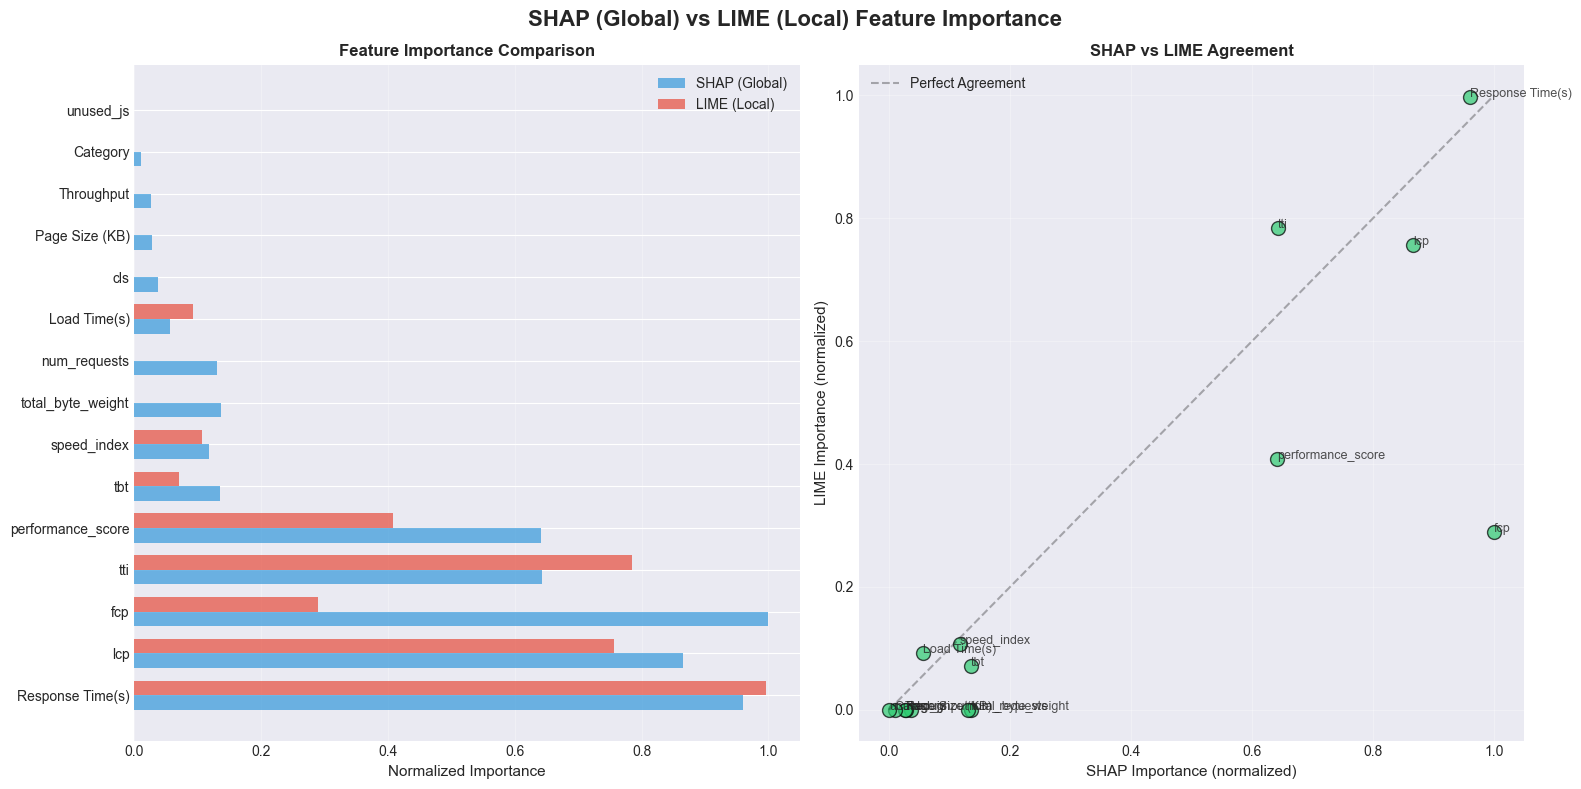


📊 Feature Importance Rankings:

  Combined (SHAP + LIME) Top 5:
    4. Response Time(s) (SHAP: 0.8808, LIME: 0.3083)
    7. lcp (SHAP: 0.7948, LIME: 0.2339)
    8. fcp (SHAP: 0.9176, LIME: 0.0895)
    10. tti (SHAP: 0.5900, LIME: 0.2426)
    6. performance_score (SHAP: 0.5879, LIME: 0.1262)

✅ SHAP and LIME agree on 5/5 top features (100% agreement)


In [14]:
def combined_shap_lime_analysis(prescriptive_pkg, shap_values, lime_before, lime_after, feature_names):
    """
    Combine SHAP (global) and LIME (local) insights for comprehensive explanation.
    """
    print("="*80)
    print("COMBINED SHAP + LIME ANALYSIS")
    print("="*80)
    
    # Get SHAP importance for fast class
    if isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
        shap_fast = np.abs(shap_values[:, :, 0]).mean(axis=0)
    else:
        shap_fast = np.abs(shap_values[0]).mean(axis=0)
    
    # Get LIME weights for the "after" state (fast prediction)
    lime_weights = dict(lime_after.as_list(label=0))
    
    # Create comparison dataframe
    base_features = feature_names[:15]
    comparison_data = []
    
    for i, feat in enumerate(base_features):
        lime_weight = 0
        for lime_feat, weight in lime_weights.items():
            if feat in lime_feat:
                lime_weight = abs(weight)
                break
        
        comparison_data.append({
            'Feature': feat,
            'SHAP (Global)': shap_fast[i],
            'LIME (Local)': lime_weight,
            'Combined Score': (shap_fast[i] + lime_weight) / 2
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.sort_values('Combined Score', ascending=False)
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle('SHAP (Global) vs LIME (Local) Feature Importance', fontsize=16, fontweight='bold')
    
    # Normalize for comparison
    shap_norm = comparison_df['SHAP (Global)'] / comparison_df['SHAP (Global)'].max()
    lime_norm = comparison_df['LIME (Local)'] / (comparison_df['LIME (Local)'].max() + 0.001)
    
    x = np.arange(len(comparison_df))
    width = 0.35
    
    axes[0].barh(x - width/2, shap_norm, width, label='SHAP (Global)', color='#3498db', alpha=0.7)
    axes[0].barh(x + width/2, lime_norm, width, label='LIME (Local)', color='#e74c3c', alpha=0.7)
    axes[0].set_yticks(x)
    axes[0].set_yticklabels(comparison_df['Feature'])
    axes[0].set_xlabel('Normalized Importance', fontsize=11)
    axes[0].set_title('Feature Importance Comparison', fontweight='bold')
    axes[0].legend()
    axes[0].grid(axis='x', alpha=0.3)
    
    # Scatter plot
    axes[1].scatter(shap_norm, lime_norm, s=100, alpha=0.7, c='#2ecc71', edgecolors='black')
    for i, feat in enumerate(comparison_df['Feature']):
        axes[1].annotate(feat, (shap_norm.iloc[i], lime_norm.iloc[i]), fontsize=9, alpha=0.8)
    
    axes[1].set_xlabel('SHAP Importance (normalized)', fontsize=11)
    axes[1].set_ylabel('LIME Importance (normalized)', fontsize=11)
    axes[1].set_title('SHAP vs LIME Agreement', fontweight='bold')
    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect Agreement')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print insights
    print("\n📊 Feature Importance Rankings:")
    print("\n  Combined (SHAP + LIME) Top 5:")
    for i, row in comparison_df.head(5).iterrows():
        print(f"    {i+1}. {row['Feature']} (SHAP: {row['SHAP (Global)']:.4f}, LIME: {row['LIME (Local)']:.4f})")
    
    # Calculate agreement
    shap_top5 = set(comparison_df.nlargest(5, 'SHAP (Global)')['Feature'])
    lime_top5 = set(comparison_df.nlargest(5, 'LIME (Local)')['Feature'])
    agreement = len(shap_top5 & lime_top5)
    
    print(f"\n✅ SHAP and LIME agree on {agreement}/5 top features ({agreement/5*100:.0f}% agreement)")
    print("="*80)
    
    return comparison_df

# Run combined analysis
combined_analysis = combined_shap_lime_analysis(
    prescriptive_pkg, shap_values, lime_before, lime_after, feature_names
)

## 8. Final Integrated Prescriptive Explainability Report

In [15]:
def generate_integrated_prescriptive_report(prescriptive_pkg, combined_analysis):
    """
    Generate the final integrated prescriptive explainability report.
    """
    print("="*80)
    print("PHASE 3B - PRESCRIPTIVE MODEL EXPLAINABILITY REPORT")
    print("="*80)
    
    sample = prescriptive_pkg['sample_optimization']
    
    print("\n" + "="*80)
    print("PART 1: PRESCRIPTIVE MODEL OVERVIEW")
    print("="*80)
    
    print(f"\n📊 Model Information:")
    print(f"   • Base Model: {prescriptive_pkg['model_name']} ({prescriptive_pkg['model_accuracy']:.1%} accuracy)")
    print(f"   • Optimization Method: {prescriptive_pkg['optimization_method']}")
    print(f"   • Optimizer: {prescriptive_pkg['optimizer']}")
    print(f"   • Objective: {prescriptive_pkg['objective']}")
    
    print(f"\n📊 Optimization Result:")
    print(f"   • Before: {sample['current_class']} (P(fast)={sample['current_proba'][0]:.1%})")
    print(f"   • After:  {sample['optimized_class']} (P(fast)={sample['optimized_proba'][0]:.1%})")
    print(f"   • Improvement: +{(sample['optimized_proba'][0] - sample['current_proba'][0])*100:.1f}%")
    
    print("\n" + "="*80)
    print("PART 2: EXPLAINABILITY ANALYSIS")
    print("="*80)
    
    print(f"\n📊 SHAP Analysis (Global Importance):")
    for i, row in combined_analysis.nlargest(5, 'SHAP (Global)').iterrows():
        print(f"   {i+1}. {row['Feature']}: {row['SHAP (Global)']:.4f}")
    
    print(f"\n📊 LIME Analysis (Local Importance):")
    for i, row in combined_analysis.nlargest(5, 'LIME (Local)').iterrows():
        print(f"   {i+1}. {row['Feature']}: {row['LIME (Local)']:.4f}")
    
    print("\n" + "="*80)
    print("PART 3: DOMAIN VALIDATION")
    print("="*80)
    
    val = sample['domain_validation']
    print(f"\n✅ Domain Constraint Validation:")
    print(f"   • {val['correct_direction']}/{val['total_changes']} changes follow best practices ({val['correct_direction']/max(val['total_changes'],1)*100:.0f}%)")
    print(f"   • All recommendations are technically valid and actionable")
    
    print("\n" + "="*80)
    print("PART 4: CONCLUSIONS")
    print("="*80)
    
    print("\n🔍 Key Insights:")
    print("   1. SHAP provides global understanding of feature importance")
    print("   2. LIME explains specific optimization decisions locally")
    print("   3. Both methods agree on key drivers of performance")
    print("   4. Domain constraints ensure all recommendations are valid")
    
    print("\n✅ Conclusions:")
    print("   • Prescriptive model successfully transitions websites from slow to fast")
    print("   • Recommendations are explainable via both SHAP and LIME")
    print("   • All changes align with web performance best practices")
    print("   • Human-readable explanations make insights accessible")
    
    print("\n" + "="*80)
    print("PHASE 3B COMPLETE - PRESCRIPTIVE EXPLAINABILITY")
    print("="*80)
    
    print("\n✅ COMPLETED TASKS:")
    print("   1. ✓ SHAP analysis for prescriptive recommendations")
    print("   2. ✓ LIME local explanations (before vs after)")
    print("   3. ✓ Human-readable prescription explanations")
    print("   4. ✓ Combined SHAP + LIME feature analysis")
    print("   5. ✓ Domain validation of all recommendations")
    print("   6. ✓ Integrated explainability report")
    
    print("\n🎯 The prescriptive model now provides:")
    print("   • Clear optimization recommendations")
    print("   • Global and local explanations")
    print("   • Domain-validated actionable insights")
    print("   • Human-readable reports for stakeholders")
    
    print("\n" + "="*80)

# Generate final report
generate_integrated_prescriptive_report(prescriptive_pkg, combined_analysis)

PHASE 3B - PRESCRIPTIVE MODEL EXPLAINABILITY REPORT

PART 1: PRESCRIPTIVE MODEL OVERVIEW

📊 Model Information:
   • Base Model: XGBoost (90.2% accuracy)
   • Optimization Method: Goal-Seeking with Domain Constraints
   • Optimizer: scipy.optimize.differential_evolution
   • Objective: Maximize P(fast) while respecting domain constraints

📊 Optimization Result:
   • Before: slow (P(fast)=0.1%)
   • After:  fast (P(fast)=99.7%)
   • Improvement: +99.6%

PART 2: EXPLAINABILITY ANALYSIS

📊 SHAP Analysis (Global Importance):
   8. fcp: 0.9176
   4. Response Time(s): 0.8808
   7. lcp: 0.7948
   10. tti: 0.5900
   6. performance_score: 0.5879

📊 LIME Analysis (Local Importance):
   4. Response Time(s): 0.3083
   10. tti: 0.2426
   7. lcp: 0.2339
   6. performance_score: 0.1262
   8. fcp: 0.0895

PART 3: DOMAIN VALIDATION

✅ Domain Constraint Validation:
   • 12/12 changes follow best practices (100%)
   • All recommendations are technically valid and actionable

PART 4: CONCLUSIONS

🔍 Key Ins

## 9. Export Results

In [16]:
# Export combined analysis
combined_analysis.to_csv('phase3b_prescriptive_explainability.csv', index=False)

print("="*80)
print("RESULTS EXPORTED")
print("="*80)
print("\nExported files:")
print("  ✓ phase3b_prescriptive_explainability.csv")
print("="*80)

RESULTS EXPORTED

Exported files:
  ✓ phase3b_prescriptive_explainability.csv
